<a href="https://colab.research.google.com/github/jasper99tai77-afk/BAPortfolio/blob/main/Portfolio_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import data and package

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

import sklearn
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, explained_variance_score
from sklearn.metrics import classification_report

In [ ]:
url = 'https://raw.githubusercontent.com/JaperTai77/data-modified/main/heart.csv'
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Column Definition:

| Variable Name | Type | Description |
| :--- | :--- | :--- |
| **cp** | Categorical | Type of chest pain the patient has. |
| **trestbps** | Integer | Resting blood pressure when going to the hospital (in mm Hg). |
| **chol** | Integer | Serum cholesterol level (in mg/dl). |
| **fbs** | Categorical | Fasting blood sugar higher than 120 mg/dl. |
| **restecg** | Categorical | Resting electrocardiographic results. |
| **thalach** | Integer | Maximum heart rate reached during exercise. |
| **exang** | Categorical | Angina caused by exercise. |
| **oldpeak** | Integer | ST depression caused by exercise compared to rest. |
| **slope** | Categorical | The slope of the peak exercise ST segment. |
| **ca** | Integer | Number of major blood vessels (0-3) colored by fluoroscopy. |
| **thal** | Categorical | Results of the thalium stress test. |
| **target (num)** | Integer | Diagnosis of heart disease (the target variable). |




# Summary and Data Visualization

In [ ]:
# View statistical summary
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


We observe that the dataset contains 303 total observations. The average age of the patients is approximately 54 years, with a range between 29 and 77 years old. The mean resting blood pressure is 131.62 mmHg and the mean serum cholesterol level is 246.26 mg/dl. The target variable has a mean of 0.54, which indicates that about 54% of the patients in this dataset have heart disease.

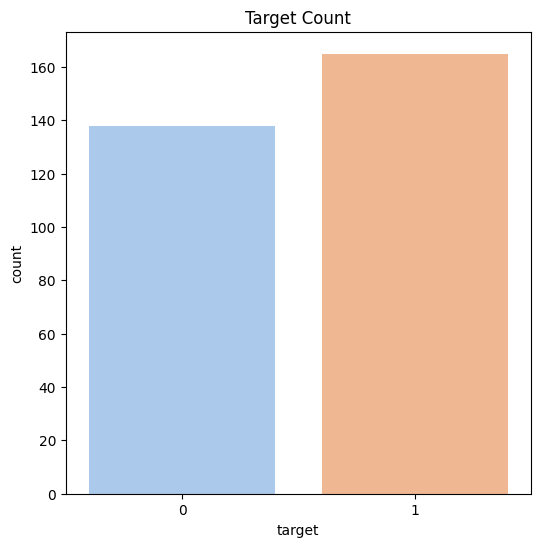

In [ ]:
plt.figure(figsize = (6,6))
sns.countplot(x = 'target', hue = 'target', legend = False, data = df, palette= 'pastel').set_title('Target Count')
plt.show()

There are slighlty more patients that have heart disease in the dataset, but not by too much.

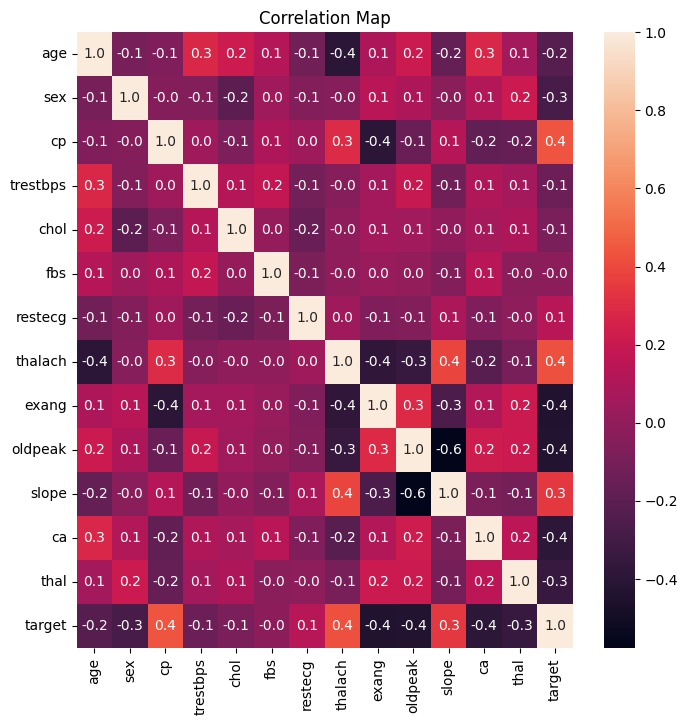

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True, fmt='.1f').set_title('Correlation Map')
plt.show()

We can consider dropping fbs because it have almost no correlation with the target variable. Also, slope and oldpeak are highly related to each other. We will monitor these and changes if necessary.

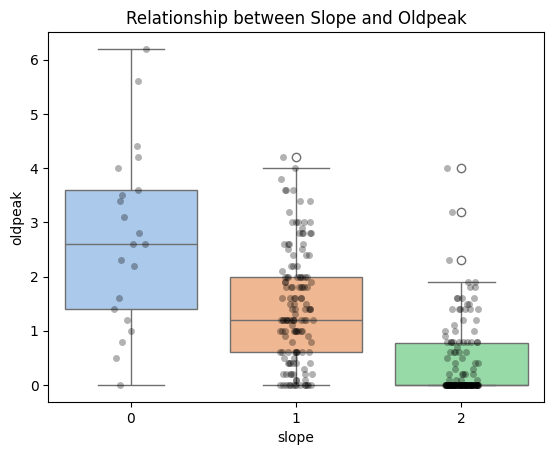

In [ ]:
sns.boxplot(x='slope', y='oldpeak', data=df, hue='slope', legend=False, palette='pastel')
sns.stripplot(x='slope', y='oldpeak', data=df, color='black', alpha=0.3, jitter=True)

plt.title('Relationship between Slope and Oldpeak')
plt.show()

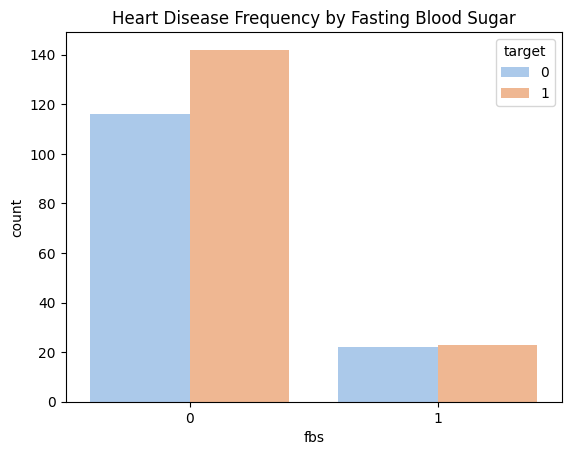

In [ ]:
sns.countplot(x='fbs', hue='target', data=df, palette='pastel')
plt.title('Heart Disease Frequency by Fasting Blood Sugar')
plt.show()

In [ ]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


The mean values show that patients with heart disease have a significantly higher average max heart rate and more chest pain than healthy patients. The  patents that have much lower angina caused by exercise, number of major blood vessels, and ST depression scores are those with heart disease.

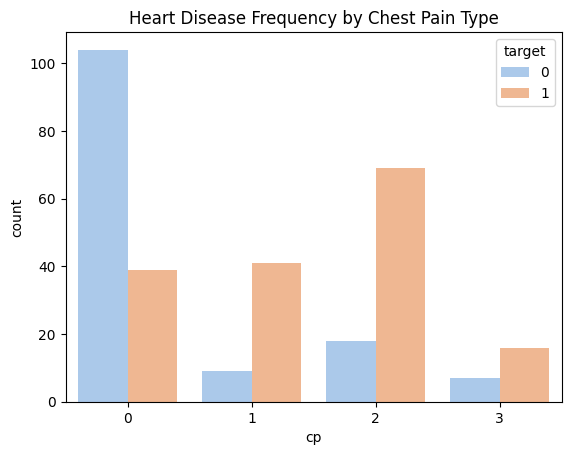

In [ ]:
sns.countplot(x='cp', hue='target', data=df, palette= 'pastel')
plt.title('Heart Disease Frequency by Chest Pain Type')
plt.show()

Chest pain category info:
  * 1: typical angina
  * 2: atypical angina
  * 3: non-anginal pain
  * 4: asymptomatic

Patients with chest pain type 0 mostly do not have heart disease. However, patients with chest pain types 1, 2, and 3 are more likely to have heart disease, with type 2 showing the highest count.

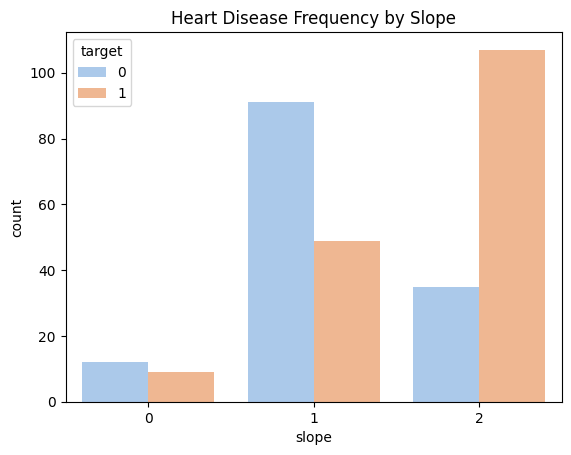

In [ ]:
sns.countplot(x='slope', hue='target', data=df, palette= 'pastel')
plt.title('Heart Disease Frequency by Slope')
plt.show()

The slope of the peak exercise ST segment info:
  * 1: upsloping
  * 2: flat
  * 3: downsloping

Patents with a slope of 1 are more likely to healthy. Patents with a slope of 2 are much more likely to have heart disease.

# Data Preprocessing

In [ ]:
# Get dummy variables
df = pd.get_dummies(df, columns = ['cp', 'thal', 'slope'], drop_first=True)
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,thal_1,thal_2,thal_3,slope_1,slope_2
0,63,1,145,233,1,0,150,0,2.3,0,1,False,False,True,True,False,False,False,False
1,37,1,130,250,0,1,187,0,3.5,0,1,False,True,False,False,True,False,False,False
2,41,0,130,204,0,0,172,0,1.4,0,1,True,False,False,False,True,False,False,True
3,56,1,120,236,0,1,178,0,0.8,0,1,True,False,False,False,True,False,False,True
4,57,0,120,354,0,1,163,1,0.6,0,1,False,False,False,False,True,False,False,True


In [ ]:
# Drop FPS column
df = df.drop(columns = ['fbs'])

In [ ]:
# Split data into X and y
X = df.drop(columns= 'target')
y = df.target
X_columns = df.drop(columns= 'target').columns

# Create a train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [ ]:
# Scale the dataset
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modeling

In [ ]:
def plot_confusion_matrix(y_test, y_pred_class, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints metrics and plots the confusion matrix.
    """
    print("Accuracy: ", metrics.accuracy_score(y_test, y_pred_class))
    print("Recall:",metrics.recall_score(y_test, y_pred_class))
    print("F1 score:",metrics.f1_score(y_test, y_pred_class))
    cm = metrics.confusion_matrix(y_test, y_pred_class)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label',fontsize=15)
    plt.xlabel('Predicted label',fontsize=15)
    plt.show()

### Logistic Regression

In [ ]:
# Train on logistic regression
from sklearn.linear_model import LogisticRegression
model_log = LogisticRegression(random_state=7)
model_log.fit(X_train, y_train)

LogisticRegression(random_state=7)

Accuracy:  0.7868852459016393
Recall: 0.8709677419354839
F1 score: 0.8059701492537313


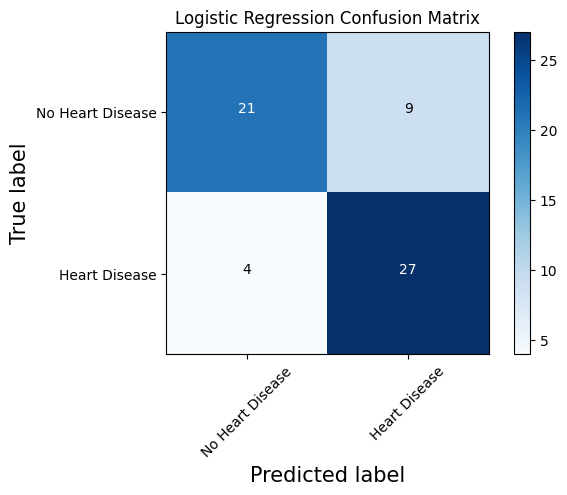

In [ ]:
# Evaluate model
y_pred_class = model_log.predict(X_test)
plot_confusion_matrix(y_test, y_pred_class, classes=['No Heart Disease', 'Heart Disease'], title='Logistic Regression Confusion Matrix')

### K-nearest Neighbors Classification

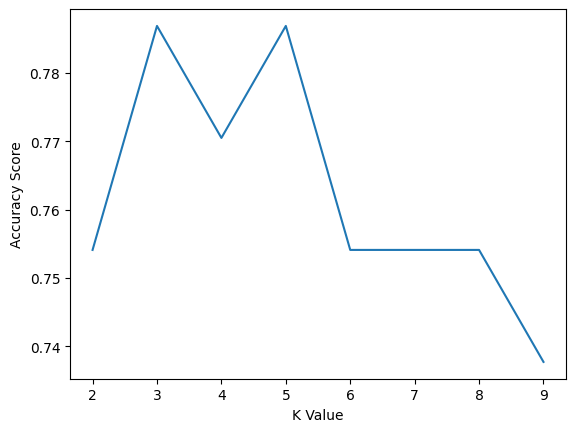

In [ ]:
# Find the optimal k
from sklearn.neighbors import KNeighborsClassifier

score = []

for i in range(2, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    ypred = knn.predict(X_test)
    score.append(accuracy_score(y_test, ypred))

plt.plot(range(2, 10), score)
plt.xticks(np.arange(2, 10, 1))
plt.xlabel("K Value")
plt.ylabel("Accuracy Score")
plt.show()

We will use k=3.

Accuracy:  0.7377049180327869
Recall: 0.7741935483870968
F1 score: 0.75


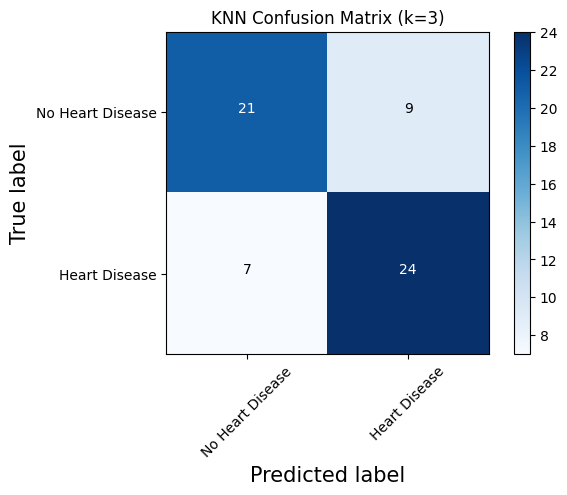

In [ ]:
# Train and evaluate KNN model
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['No Heart Disease', 'Heart Disease'], title='KNN Confusion Matrix (k=3)')

### Supportive Vector Machine Classifier

In [ ]:
# Run a grid search to find optimal parameter
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 1, 10], 'kernel': ['linear','rbf','poly','sigmoid']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=2)

Accuracy:  0.7377049180327869
Recall: 0.8709677419354839
F1 score: 0.7714285714285715


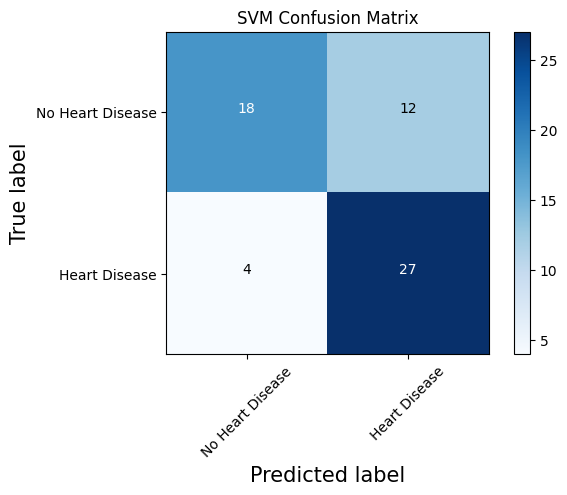

In [ ]:
# Evaluate model
y_pred = grid.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['No Heart Disease', 'Heart Disease'], title='SVM Confusion Matrix')

### Naive Bayes Classifier

In [ ]:
# Train on Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

GaussianNB()

Accuracy:  0.8032786885245902
Recall: 0.8387096774193549
F1 score: 0.8125


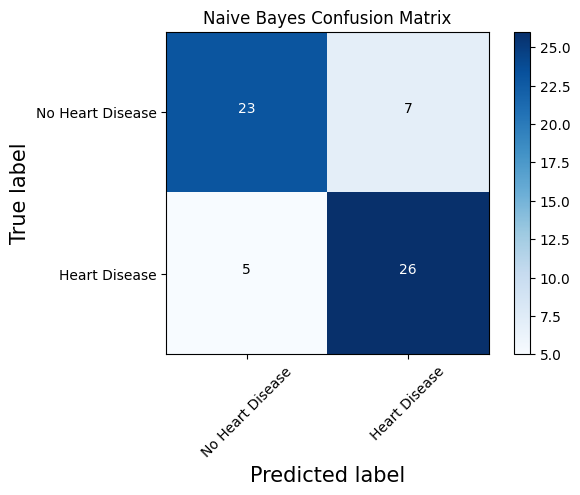

In [ ]:
# Evaluate model
y_pred = model_nb.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['No Heart Disease', 'Heart Disease'], title='Naive Bayes Confusion Matrix')

### Decision Tree Classifer

In [ ]:
# Run a grid search to find optimal parameter
from sklearn.tree import DecisionTreeClassifier

param_grid = {'max_depth': [5,10,20,50], 'min_samples_leaf': [2,5,10], 'max_leaf_nodes': [10,20,50,100]}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=2; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.0s
[CV] END .max_depth=5, max_leaf_nodes=10, min_samples_leaf=5; total time=   0.0s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=10; total time=   0.0s
[CV] END max_depth=5, max_leaf_nodes=10, min_sa

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [5, 10, 20, 50],
                         'max_leaf_nodes': [10, 20, 50, 100],
                         'min_samples_leaf': [2, 5, 10]},
             verbose=2)

Accuracy:  0.7213114754098361
Recall: 0.8064516129032258
F1 score: 0.746268656716418


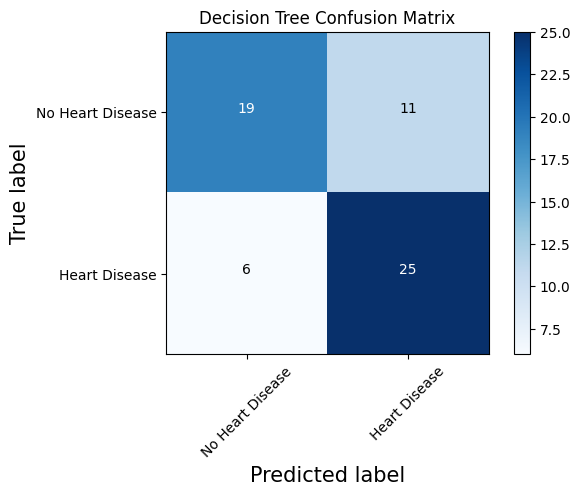

In [ ]:
# Evaluate model
y_pred = grid.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['No Heart Disease', 'Heart Disease'], title='Decision Tree Confusion Matrix')

### Random Forest Classifer

In [ ]:
# Run a grid search to find optimal parameter
from sklearn.ensemble import RandomForestClassifier

param_grid = {'n_estimators': [10,50,100], 'max_depth': [5,10,20,50], 'min_samples_leaf': [2,5,10], 'max_leaf_nodes': [10,20,50,100]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.2s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=10; total time=   0.1s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=5, max_leaf_nodes=10, min_samples_leaf=2, n_e

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 20, 50],
                         'max_leaf_nodes': [10, 20, 50, 100],
                         'min_samples_leaf': [2, 5, 10],
                         'n_estimators': [10, 50, 100]},
             verbose=2)

Accuracy:  0.7868852459016393
Recall: 0.8709677419354839
F1 score: 0.8059701492537313


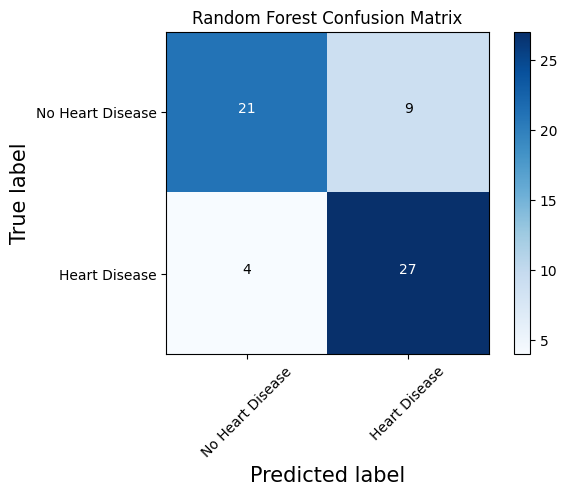

In [ ]:
# Evaluate model
y_pred = grid.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['No Heart Disease', 'Heart Disease'], title='Random Forest Confusion Matrix')

### XGBoost

In [ ]:
# Train model with XGBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state=7)
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Accuracy:  0.7704918032786885
Recall: 0.8387096774193549
F1 score: 0.7878787878787878


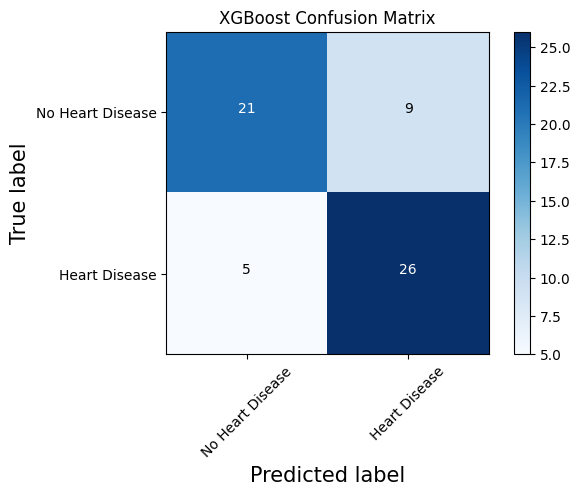

In [ ]:
# Evaluate model
y_pred = model_xgb.predict(X_test)
plot_confusion_matrix(y_test, y_pred, classes=['No Heart Disease', 'Heart Disease'], title='XGBoost Confusion Matrix')

# Model Perfomance Overview

### Logistic Regression
With our validation data, the accuracy is around 79% and it only missed 4 false negatives.

### K-nearest Neighbors
The accuracy is around 74%. The recall and F1 score are worse than the logistic regression model, indicating we missed a lot of potential heart disease patients.

### Supportive Vector Machine
The accuracy is around 74%, but the recall matches with the logistic regression.

### Naive Bayes
It has the hghest accuracy at around 80%. However, the recall is lower than logistic regression and missed 5 patients (False Negative).

### Decision Tree
The accuracy is around 72%. It has 6 False Negatives and the lowest accuracy.

### Random Forest
The accuracy is around 79% and the result is identical to logistic regression.

### XGBoost
The accuracy is around 77% and missed 5 false negative.

For this medical problem, finding potential heart disease patients is the most important goal. We'll focus on the recall score first because we want the lowest number of false negatives. The Random Forest and Logistic Regression classifier give us the highest recall which meets our primary goal.